In [ ]:
import numpy as np # For numerical operations on arrays
import pandas as pd  # For data analysis and manipulation
import os
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import tensorflow as tf
import keras
from keras.preprocessing import image
from keras.models import Sequential
from keras.layers import Conv2D, MaxPool2D, Flatten,Dense,Dropout,BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import cv2
from keras import regularizers
from tensorflow.keras.optimizers import Adam

In [ ]:
import os
import zipfile


zip_path = "/content/drive/MyDrive/Emotion_Dataset/archive.zip"

extract_path = "/content/fer2013_fast"

print("Unzipping data to local runtime")

if not os.path.exists(extract_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("Unzip Complete! Data is ready.")
else:
    print("Data is already loaded locally.")


base_dir = extract_path

print("Folders found:", os.listdir(base_dir))

train_dir = os.path.join(base_dir, 'train')
test_dir = os.path.join(base_dir, 'test')

Unzipping data to local runtime
Unzip Complete! Data is ready.
Folders found: ['train', 'test']


In [ ]:
from collections import Counter
import os

emotion_counts = {}

for emotion in os.listdir(train_dir):
    emotion_path = os.path.join(train_dir, emotion)
    if os.path.isdir(emotion_path):
        emotion_counts[emotion] = len(os.listdir(emotion_path))

for emotion, count in emotion_counts.items():
    print(f"{emotion}: {count}")


surprised: 3171
neutral: 4965
angry: 3995
sad: 4830
disgusted: 436
happy: 7215
fearful: 4097


In [ ]:
train_datagen = ImageDataGenerator(
width_shift_range=0.1,
height_shift_range=0.1,
horizontal_flip=True,
rescale=1./255,
validation_split=0.2
)
test_datagen = ImageDataGenerator(rescale=1./255)

In [ ]:
# RAM will overflow when load all images so we load in batches
train_generator = train_datagen.flow_from_directory(
directory=train_dir,
target_size=(48, 48),
batch_size=64,    # how many images should load in batch
color_mode="grayscale",
class_mode="categorical",   # more than one class
subset="training",            # 80 percent data
shuffle=True              #It shuffles the order of images every epoch. If you didn't shuffle, the model might memorize the order

)

validation_generator = train_datagen.flow_from_directory(
directory=train_dir,  # Use train_dir for validation
target_size=(48, 48),
batch_size=64,
color_mode="grayscale",
class_mode="categorical",
subset="validation",
shuffle=False        #don't shuffle validation data because we just need to check accuracy

)
test_generator = test_datagen.flow_from_directory(
directory=test_dir,
target_size=(48, 48),
batch_size=64,
color_mode="grayscale",
class_mode="categorical",
shuffle=False       #predictions to match the order of the file names,If you shuffle here, you won't know which prediction belongs to which image
)

Found 22968 images belonging to 7 classes.
Found 5741 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


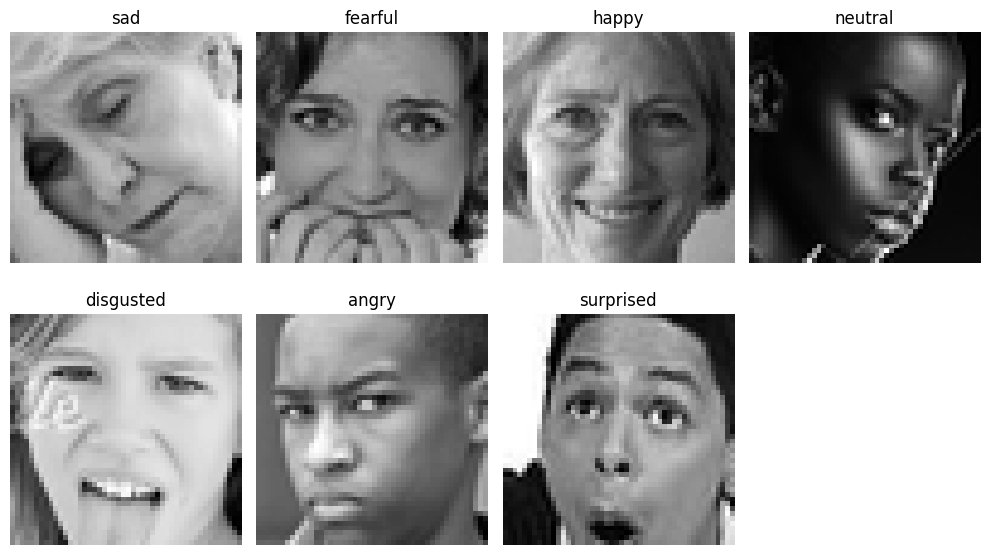

In [ ]:
categories = os.listdir(train_dir)

plt.figure(figsize=(10, 6))

for i, category in enumerate(categories):
    category_path = os.path.join(train_dir, category)
    image_path = os.path.join(category_path, os.listdir(category_path)[0])  # Get first image
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)  # Read in grayscale #cv2.read is read the image
    plt.subplot(2, 4, i+1) # cv2 helps in image processing ,grayscale used to see in black white
    plt.imshow(image, cmap='gray') # 2 and 4  means 2 rows and 4 columns , cmap help to show image in gray
    plt.title(category) # otherwise it will show in blue , imshow is used to display , title show that it is happy
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
#Class weights modify the loss function during training to make the model care more about mistakes on minorit
#Higher weight = model pays more attention to that class.
#weight = total_samples / (num_classes × samples_in_class)
from sklearn.utils.class_weight import compute_class_weight
class_weights = compute_class_weight(
class_weight='balanced',
classes=np.unique(train_generator.classes),
y=train_generator.classes
)
class_weight_dict = dict(enumerate(class_weights))
print("Class weights:", class_weight_dict)


Class weights: {0: np.float64(1.0266404434114071), 1: np.float64(9.401555464592715), 2: np.float64(1.0009587727708533), 3: np.float64(0.5684585684585685), 4: np.float64(0.826068191627104), 5: np.float64(0.8491570541259982), 6: np.float64(1.2933160650937552)}


In [ ]:
#Convolutional Layers are eyes; they scan the image to find patterns
#BatchNorm: It stabilizes the learning process and allows the model to train faster.
#ReLU: allowing the model to learn complex patterns (not just straight lines).
#MaxPooling: Reduces size, keeps important data.
#padding: output feature has the same height and width as the input,
#Dropout: prevents the network from relying too heavily on any single neuron (overfitting).
#Flatten: Turns the 2D image grid into a long 1D list of numbers.
#Converts the raw numbers (logits) into probabilities.
#Dense Layers are the brain; they take those patterns and make a final decision.

model = tf.keras.Sequential([
        # input layer ,This layer only learns to see lines, curves, and edges. It doesn't know what a face is.
        tf.keras.layers.Input(shape=(48,48,1)),
        tf.keras.layers.Conv2D(64,(3,3), padding='same', activation='relu' ),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D(2,2),
        tf.keras.layers.Dropout(0.25),

         # 1st hidden dense layer , Two curves make a circle (maybe an eye) or "Two lines meeting make a corner.
        tf.keras.layers.Conv2D(128,(5,5), padding='same', activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D(2,2),
        tf.keras.layers.Dropout(0.25),

        # 2nd hidden dense layer ,It recognizes "This is a nose," "This is a mouth," "This is an eyebrow."
        tf.keras.layers.Conv2D(512,(3,3), padding='same', activation='relu',kernel_regularizer=tf.keras.regularizers.l2(0.01)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D(2,2),
        tf.keras.layers.Dropout(0.25),

        # 3rd hidden dense layer , If the corners of the mouth are up AND the eyes are crinkled = Happy.
        tf.keras.layers.Conv2D(512,(3,3), padding='same', activation='relu',kernel_regularizer=tf.keras.regularizers.l2(0.01)), #
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D(2,2),
        tf.keras.layers.Dropout(0.25),

         # Flatten layer
        tf.keras.layers.Flatten(),

        tf.keras.layers.Dense(256, activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.25),

        tf.keras.layers.Dense(512, activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.25),

        # output layer
        tf.keras.layers.Dense(7, activation='softmax')
    ])

In [ ]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)
model.compile(optimizer=optimizer,
loss='categorical_crossentropy',
metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 128)    │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 512)    │       590,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 6, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 6, 6, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │             

 Total params: 4,478,727 (17.08 MB)

 Trainable params: 4,474,759 (17.07 MB)

 Non-trainable params: 3,968 (15.50 KB)

In [ ]:
history = model.fit(
  train_generator,
  validation_data=validation_generator,
  epochs=50,
  class_weight=class_weight_dict,
  callbacks=[
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=3)
  ]
)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


359/359 ━━━━━━━━━━━━━━━━━━━━ 53s 103ms/step - accuracy: 0.1686 - loss: 9.7174 - val_accuracy: 0.1373 - val_loss: 9.8224 - learning_rate: 1.0000e-04
Epoch 2/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 23s 64ms/step - accuracy: 0.1767 - loss: 8.9708 - val_accuracy: 0.1416 - val_loss: 8.3142 - learning_rate: 1.0000e-04
Epoch 3/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 23s 63ms/step - accuracy: 0.1848 - loss: 8.2674 - val_accuracy: 0.2036 - val_loss: 7.6014 - learning_rate: 1.0000e-04
Epoch 4/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 23s 63ms/step - accuracy: 0.1984 - loss: 7.5348 - val_accuracy: 0.2130 - val_loss: 6.8391 - learning_rate: 1.0000e-04
Epoch 5/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 23s 64ms/step - accuracy: 0.2121 - loss: 6.8233 - val_accuracy: 0.2318 - val_loss: 6.1239 - learning_rate: 1.0000e-04
Epoch 6/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 23s 63ms/step - accuracy: 0.2193 - loss: 6.1338 - val_accuracy: 0.2733 - val_loss: 5.4550 - learning_rate: 1.0000e-04
Epoch 7/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 23s 63ms/step - accura

In [ ]:

model.save('/content/drive/MyDrive/models/emotion_custommodel60.h5')

In [ ]:
from sklearn.metrics import classification_report
# Get predictions
y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_generator.classes
# Show per-class performance
print(classification_report(y_true, y_pred_classes,
target_names=list(train_generator.class_indices.keys())))

113/113 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step
              precision    recall  f1-score   support

       angry       0.51      0.62      0.56       958
   disgusted       0.37      0.71      0.48       111
     fearful       0.56      0.28      0.37      1024
       happy       0.87      0.81      0.84      1774
     neutral       0.55      0.66      0.60      1233
         sad       0.51      0.50      0.50      1247
   surprised       0.71      0.81      0.76       831

    accuracy                           0.63      7178
   macro avg       0.58      0.63      0.59      7178
weighted avg       0.63      0.63      0.62      7178



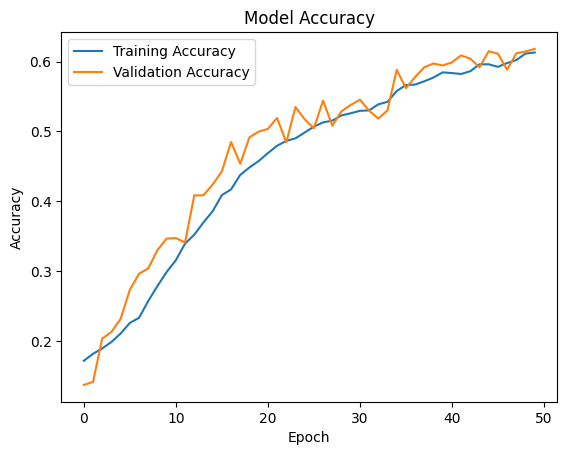

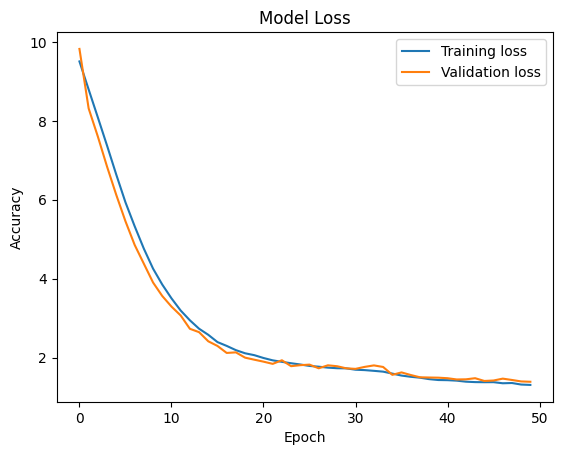

In [ ]:
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


plt.plot(history.history["loss"], label="Training loss")
plt.plot(history.history["val_loss"], label="Validation loss")
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [ ]:
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test Accuracy: {test_acc * 100:.2f}%")

113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.5889 - loss: 1.4771
Test Accuracy: 62.55%


In [ ]:
#Of all the times the model predicted "Happy," how many times was it actually right?
#precision
#Of all the actual "Happy" faces that exist in the dataset, how many did the model manage to find?
#recall
#The combined score of Precision and Recall. It is the harmonic mean (average) of the two.
#f1

Loading model from /content/drive/MyDrive/models/emotion_custommodel60.h5...


Model loaded successfully!
Preparing Test Data...
Found 7178 images belonging to 7 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Predicting classes...
113/113 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step

CLASSIFICATION REPORT: /content/drive/MyDrive/models/emotion_custommodel60.h5
              precision    recall  f1-score   support

       angry       0.51      0.62      0.56       958
   disgusted       0.37      0.71      0.48       111
     fearful       0.56      0.28      0.37      1024
       happy       0.87      0.81      0.84      1774
     neutral       0.55      0.66      0.60      1233
         sad       0.51      0.50      0.50      1247
   surprised       0.71      0.81      0.76       831

    accuracy                           0.63      7178
   macro avg       0.58      0.63      0.59      7178
weighted avg       0.63      0.63      0.62      7178


CONFUSION MATRIX


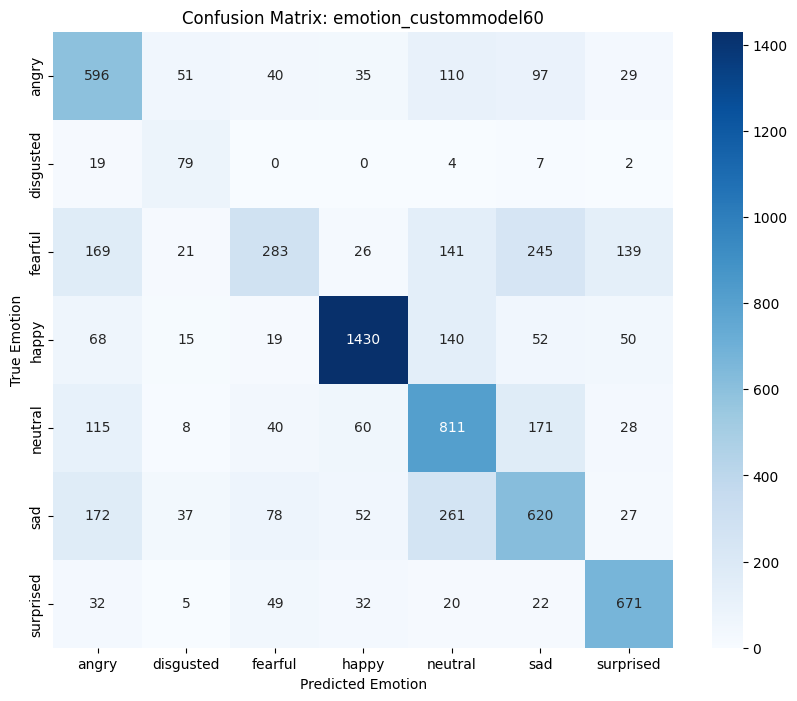

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# --- 1. CONFIGURATION FOR CUSTOM MODEL 60 ---
# This path matches the one in your MoodMate7 notebook
MODEL_PATH = '/content/drive/MyDrive/models/emotion_custommodel60.h5'

# CRITICAL: MoodMate7 used 48x48 and Grayscale [cite: 769, 722]
IMG_HEIGHT, IMG_WIDTH = 48, 48
COLOR_MODE = 'grayscale'

TEST_DIR = '/content/fer2013_fast/test' # Path to test data
BATCH_SIZE = 64

# --- 2. LOAD MODEL & PREPARE DATA ---
print(f"Loading model from {MODEL_PATH}...")
try:
    model = load_model(MODEL_PATH)
    print("Model loaded successfully!")
except Exception as e:
    print(f"Error loading model: {e}")

print("Preparing Test Data...")
test_datagen = ImageDataGenerator(rescale=1./255) # Normalize like training [cite: 685]

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    color_mode=COLOR_MODE, # 'grayscale' is vital here
    class_mode='categorical',
    shuffle=False # Must be False for correct confusion matrix
)

# --- 3. GENERATE PREDICTIONS ---
print("Predicting classes...")
predictions = model.predict(test_generator)
y_pred = np.argmax(predictions, axis=1)
y_true = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

# --- 4. CLASSIFICATION REPORT ---
print("\n" + "="*50)
print(f"CLASSIFICATION REPORT: {MODEL_PATH}")
print("="*50)
print(classification_report(y_true, y_pred, target_names=class_labels))

# --- 5. CONFUSION MATRIX ---
print("\n" + "="*50)
print("CONFUSION MATRIX")
print("="*50)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels,
            yticklabels=class_labels)
plt.title(f'Confusion Matrix: emotion_custommodel60')
plt.ylabel('True Emotion')
plt.xlabel('Predicted Emotion')
plt.show()

# The original training history (accuracy and loss plots) is typically generated right after training.
# Since this cell is loading a pre-trained model, the 'history' object from its original training
# is not available unless it was explicitly saved and reloaded. Cell qNpxNiQ8n5Im already plots this history.
# Removing the history plotting from here to avoid NameError when evaluating a loaded model.
# If you wish to plot the history of the loaded model, you would need to save the history
# as a separate file during training and load it here.

In [ ]:
zip_path = '/content/drive/MyDrive/Emotion_Dataset/archive (1).zip'
extract_to = '/content/lastfm-fast'

!unzip -o "{zip_path}" -d "{extract_to}"
print("Extraction complete!")

Archive:  /content/drive/MyDrive/Emotion_Dataset/archive (1).zip
  inflating: /content/lastfm-fast/MP3-Example/Blues/Blues-TRACOHF128F1498509.mp3  
  inflating: /content/lastfm-fast/MP3-Example/Blues/Blues-TRADWSG128F4259317.mp3  
  inflating: /content/lastfm-fast/MP3-Example/Blues/Blues-TRAELUY128F93147BA.mp3  
  inflating: /content/lastfm-fast/MP3-Example/Blues/Blues-TRAHVWB128F9308FB0.mp3  
  inflating: /content/lastfm-fast/MP3-Example/Blues/Blues-TRAJGIO128F92E84BC.mp3  
  inflating: /content/lastfm-fast/MP3-Example/Blues/Blues-TRAOPNA128F427E83F.mp3  
  inflating: /content/lastfm-fast/MP3-Example/Blues/Blues-TRAQGFP128E078FAB6.mp3  
  inflating: /content/lastfm-fast/MP3-Example/Blues/Blues-TRARJEK128F930B3AA.mp3  
  inflating: /content/lastfm-fast/MP3-Example/Blues/Blues-TRATLTV128F92FC979.mp3  
  inflating: /content/lastfm-fast/MP3-Example/Blues/Blues-TRAUJPR128F92CA3AF.mp3  
  inflating: /content/lastfm-fast/MP3-Example/Blues/Blues-TRAUYOD128F42647FE.mp3  
  inflating: /content/

In [ ]:
import pandas as pd
import ast

music_csv_path = '/content/lastfm-fast/Music Info.csv'

#Load
df_music = pd.read_csv(music_csv_path)

print("Columns in dataset:", df_music.columns)
print("-" * 30)
print(df_music.head())

Columns in dataset: Index(['track_id', 'name', 'artist', 'spotify_preview_url', 'spotify_id',
       'tags', 'genre', 'year', 'duration_ms', 'danceability', 'energy', 'key',
       'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness',
       'liveness', 'valence', 'tempo', 'time_signature'],
      dtype='object')
------------------------------
             track_id             name           artist  \
0  TRIOREW128F424EAF0   Mr. Brightside      The Killers   
1  TRRIVDJ128F429B0E8       Wonderwall            Oasis   
2  TROUVHL128F426C441  Come as You Are          Nirvana   
3  TRUEIND128F93038C4      Take Me Out  Franz Ferdinand   
4  TRLNZBD128F935E4D8            Creep        Radiohead   

                                 spotify_preview_url              spotify_id  \
0  https://p.scdn.co/mp3-preview/4d26180e6961fd46...  09ZQ5TmUG8TSL56n0knqrj   
1  https://p.scdn.co/mp3-preview/d012e536916c927b...  06UfBBDISthj1ZJAtX4xjj   
2  https://p.scdn.co/mp3-preview/a1c11bb1c

In [ ]:
mood_mapping = {
    'Happy': ['happy', 'joy', 'upbeat', 'dance', 'party', 'fun', 'cheerful'],
    'Sad': ['sad', 'melancholy', 'grief', 'depressing', 'cry', 'heartbreak'],
    'Angry': ['angry', 'aggressive', 'hate', 'furious', 'brutal'],
    'Neutral': ['calm', 'relax', 'ambient', 'chill', 'study', 'instrumental'],
    'Fearful': ['dark', 'creepy', 'horror', 'scary', 'spooky', 'suspense'],
    'Surprised': ['experimental', 'glitch', 'unexpected', 'weird'],
    'Disgusted': ['gross', 'grotesque']
}


def get_song_mood(row):
    #  Check Tags (Text)
    tags = row['tags']
    if isinstance(tags, str):
        try:
            tags = ast.literal_eval(tags)
        except:
            tags = [tags]

    # Look for strong mood keywords in tags
    found_moods = []
    if isinstance(tags, list):
        for tag in tags:
            tag_lower = str(tag).lower()
            for mood, keywords in mood_mapping.items():
                if any(k in tag_lower for k in keywords):
                    found_moods.append(mood)

    # If we found a specific mood tag (e.g., "sad"), return it
    if found_moods:
        return max(set(found_moods), key=found_moods.count)

    # Fallback to Audio Features (Numbers)
    # If no specific mood tags found (or just generic genres like 'Rock'), use Valence/Energy
    valence = row['valence']   # Positivity (0.0 to 1.0)
    energy = row['energy']     # Intensity (0.0 to 1.0)

    if valence >= 0.6 and energy >= 0.5:
        return 'Happy'
    elif valence <= 0.4 and energy <= 0.5:
        return 'Sad'
    elif energy >= 0.7 and valence <= 0.5:
        return 'Angry'
    elif energy <= 0.4 and valence >= 0.5:
        return 'Neutral'
    else:
        return 'Neutral'


# Note: axis=1 is required to access multiple columns (tags, valence, energy)
df_music['emotion_label'] = df_music.apply(get_song_mood, axis=1)

print(df_music[['name', 'artist', 'emotion_label']].head(15))



                 name                 artist emotion_label
0      Mr. Brightside            The Killers         Angry
1          Wonderwall                  Oasis         Happy
2     Come as You Are                Nirvana       Neutral
3         Take Me Out        Franz Ferdinand       Neutral
4               Creep              Radiohead           Sad
5    Somebody Told Me            The Killers         Happy
6        Viva la Vida               Coldplay       Neutral
7        Karma Police              Radiohead       Neutral
8       The Scientist               Coldplay           Sad
9              Clocks               Coldplay       Neutral
10   Under the Bridge  Red Hot Chili Peppers         Happy
11  Seven Nation Army      The White Stripes           Sad
12     Feel Good Inc.               Gorillaz         Happy
13         Chop Suey!       System of a Down         Angry
14            Fix You               Coldplay           Sad


In [ ]:
save_path = '/content/drive/MyDrive/Dataset/lastfm/processed_music_data.csv'
df_music.to_csv(save_path, index=False)

print(f"Cleaned data saved to: {save_path}")

Cleaned data saved to: /content/drive/MyDrive/Dataset/lastfm/processed_music_data.csv


In [ ]:
# 1. Apply the logic to create a new 'Mood' column
print("Labeling songs with moods... This might take a moment.")
df_music['mood'] = df_music.apply(get_song_mood, axis=1)

# 2. Check the results
print("\nMood Distribution:")
print(df_music['mood'].value_counts())

# 3. Save this processed data so you don't have to run it again
df_music.to_csv('/content/drive/MyDrive/models/music_with_moods.csv', index=False)
print("\nSaved to 'music_with_moods.csv'!")

Labeling songs with moods... This might take a moment.

Mood Distribution:
mood
Neutral      17429
Angry        14014
Happy        12508
Sad           5003
Surprised     1729
Name: count, dtype: int64

Saved to 'music_with_moods.csv'!


In [ ]:
def recommend_music(detected_emotion, num_songs=5):
    # 1. Map Face Emotion to Music Mood
    # (Sometimes 'Fear' needs 'Calm' music, sometimes 'Scary'.
    #  For this app, let's map Fear/Angry -> Calm to soothe the user,
    #  or map them directly to matching energy. Adjust as you like!)

    # Simple direct mapping
    mood_mapping = {
        'Happy': 'Happy',
        'Sad': 'Sad',
        'Angry': 'Neutral',   # soothing music for angry users
        'Disgusted': 'Neutral',
        'Fearful': 'Neutral', # calming music for fear
        'Surprised': 'Happy', # energetic music
        'Neutral': 'Neutral'
    }

    target_mood = mood_mapping.get(detected_emotion, 'Neutral')

    # 2. Filter the dataset
    recommended_songs = df_music[df_music['mood'] == target_mood]

    # 3. Pick random songs
    if len(recommended_songs) > 0:
        # Get random sample
        if len(recommended_songs) > num_songs:
            results = recommended_songs.sample(n=num_songs)
        else:
            results = recommended_songs

        # 4. Format the output
        print(f"\n--- Detected: {detected_emotion} | Playing: {target_mood} Music ---")
        for idx, row in results.iterrows():
            print(f"🎵 {row['name']} - {row['artist']}")
            # print(f"   (Link: {row['spotify_preview_url']})") # Uncomment if you want links

        return results
    else:
        print(f"No songs found for mood: {target_mood}")
        return None

# --- TEST IT ---
# Pretend the model saw a "Happy" face
recommend_music("Happy")

# Pretend the model saw a "Sad" face
print("\n")
recommend_music("Sad")


--- Detected: Happy | Playing: Happy Music ---
🎵 Chainsaw Breakfast - Sixtoo
🎵 I'm Gonna Love You Too - Blondie
🎵 Franklin's Tower - Grateful Dead
🎵 Beinhart - Torfrock
🎵 Yearnin' - The Black Keys



--- Detected: Sad | Playing: Sad Music ---
🎵 Can't Help But Smiling - Devendra Banhart
🎵 I Started A Joke - Bee Gees
🎵 Same Old Lang Syne - Dan Fogelberg
🎵 Hejira - Joni Mitchell
🎵 Vacant - Dream Theater


,track_id,name,artist,spotify_preview_url,spotify_id,tags,genre,year,duration_ms,danceability,...,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,emotion_label,mood
25338,TRJMZNC128F931626B,Can't Help But Smiling,Devendra Banhart,https://p.scdn.co/mp3-preview/a8f986cc1fa948be...,3FXSEPzqG2DxdWPflWMput,"indie, folk, singer_songwriter, psychedelic",NaN,2009,144360,0.765,...,1,0.0421,0.146,0.00256,0.1430,0.3820,135.817,4,Sad,Sad
10551,TRDDOCT128F4220B66,I Started A Joke,Bee Gees,https://p.scdn.co/mp3-preview/256fcfbaf2bbf734...,0ibermI0DaGX5Nm7pt1QeQ,"pop, classic_rock, 70s, 60s, male_vocalists, o...",NaN,2014,186733,0.451,...,1,0.0269,0.297,0.00000,0.2550,0.2820,147.941,4,Sad,Sad
50006,TRVATNU128F42720A9,Same Old Lang Syne,Dan Fogelberg,https://p.scdn.co/mp3-preview/c0a00b4b946bdc4e...,0fpP4p1h5ZoKGs5OK63i47,"singer_songwriter, 70s",NaN,1995,320293,0.401,...,1,0.0296,0.758,0.00000,0.1710,0.3030,106.890,4,Sad,Sad
48592,TRCKYUB128F426C902,Hejira,Joni Mitchell,https://p.scdn.co/mp3-preview/84dd2a77effb6a0f...,0Faave8C9tCDeMYDBJTkhi,"female_vocalists, folk, singer_songwriter",NaN,2007,402653,0.364,...,1,0.0364,0.893,0.00757,0.0734,0.2120,170.676,4,Sad,Sad
8409,TRUERMP128F148ABBF,Vacant,Dream Theater,https://p.scdn.co/mp3-preview/6525052bde51d7be...,38SjoujHMwFDzT4Ae9K9Ht,"metal, progressive_rock, progressive_metal",Rock,2003,177373,0.150,...,0,0.0340,0.396,0.05560,0.1090,0.0521,173.914,3,Sad,Sad
